## Loading Datasets, KDEs, evaluation on grid (Compactness column of Table 1)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# # Model definitions
MODELS = {
    "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra23: ST+PDT"),
    "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra23: ST+PST"),
    "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra23: PDT--U"),
    "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra23: ST--U"),
    "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="datafiles/PDT_U26",  color="tab:olive",  label="Kini26: PDT--U"),
}

# constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 2.99792458e8      # m s^-1
M_sun = 1.98847e30    # kg

# Load Data and compute compactness
compactness = {}
KDEs_1D = {}
C_med = {}
C_lo = {}
C_hi = {}
S_i = {}
for key, meta in MODELS.items():
    filename = meta["file"]

    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]

    # Unit conversions
    M_si = M * M_sun     # solar masses → kg
    R_si = R * 1e3       # km → m

    # Compactness C = GM / (Rc^2)
    C = G * M_si / (R_si * c**2)
    compactness[key] = C

    # Summary statistics
    C_med[key] = np.median(C)
    C_lo[key] = np.min(C)
    C_hi[key] = np.max(C)
    S_i[key] = max(C_hi[key]- C_med[key], C_med[key]- C_lo[key])
    C_min = min(C_lo.values())
    C_max = max(C_hi.values())

    print(
        rf"{meta['label']}: "
        rf"${C_med[key]:.4f}^{{+{C_hi[key]:.4f}}}_{{-{C_lo[key]:.4f}}}$"
    )

    # KDE
    KDEs_1D[key] = gaussian_kde(C, bw_method="silverman")


# Evaluate KDEs on grid
C_grid = np.linspace(C_min, C_max, 200)
dC = C_grid[1] - C_grid[0]

KDE_grid_values = {}
for key, kde in KDEs_1D.items():
    pdf = kde.evaluate(C_grid)
    KDE_grid_values[key] = pdf / np.trapz(pdf, C_grid)  # normalize

Riley19: ST+PST: $0.1533^{+0.1895}_{-0.1088}$
Vinciguerra23: ST+PDT: $0.1773^{+0.1970}_{-0.1301}$
Vinciguerra23: ST+PST: $0.1880^{+0.2069}_{-0.1582}$
Vinciguerra23: PDT--U: $0.1791^{+0.2100}_{-0.1004}$
Vinciguerra23: ST--U: $0.1861^{+0.2094}_{-0.1268}$
Miller19: 2spot: $0.1603^{+0.1932}_{-0.1252}$
Miller19: 3spot: $0.1631^{+0.1962}_{-0.1250}$
Kini26: PDT--U: $0.1689^{+0.2122}_{-0.1066}$


## Plot individual distributions in Compactness

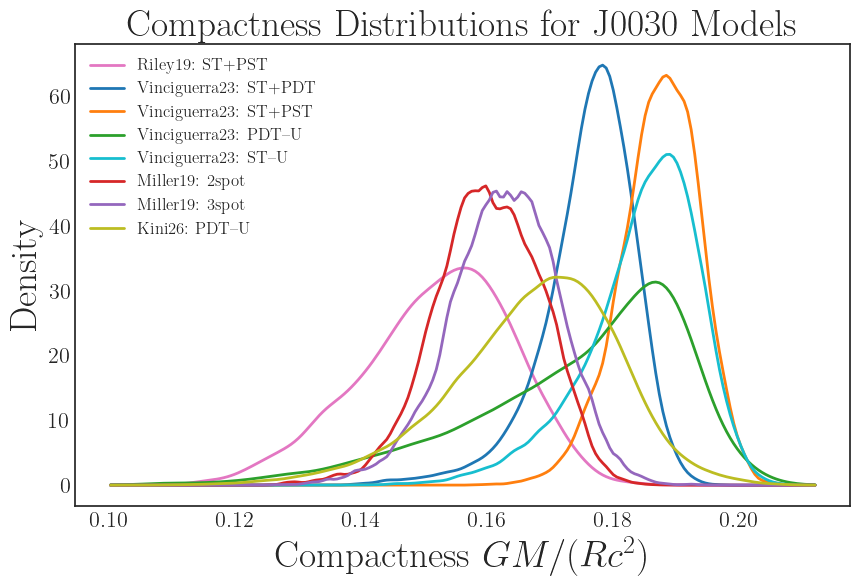

In [5]:
# Plot
plt.style.use("seaborn-v0_8-white")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

fig, ax = plt.subplots(figsize=(10, 6))

for key, meta in MODELS.items():
    ax.plot(
        C_grid,
        KDE_grid_values[key],
        color=meta["color"],
        lw=2,
        label=meta["label"]
    )

ax.set_xlabel("Compactness $GM/(Rc^2)$", fontsize=27)
ax.set_ylabel("Density", fontsize=27)
ax.set_title("Compactness Distributions for J0030 Models", fontsize=27)

ax.tick_params(labelsize=16)
ax.legend(fontsize=12)

fig.savefig(
    "/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDECompactnessVariousModels.png",
    dpi=300
)

# plt.show()

## Combination with F_good = Original KDE and F_bad = Broad Gaussian (width S, shifted by delta, rescaled by alpha)

In [6]:
# Grids and priors
sigma_grid = np.logspace(-4, -0.5, 15)
alpha_grid = np.linspace(1.0, 5.0, 30)
p_grid     = np.linspace(0.0, 1.0, 60)
# delta_grid depends on sigma (constructed inside loop)

prior_sigma = 1.0 / sigma_grid
prior_sigma /= np.trapz(prior_sigma, sigma_grid)

prior_alpha = np.exp(-alpha_grid)
prior_alpha /= np.trapz(prior_alpha, alpha_grid)

# Good and bad distributions
g_dict = {}
for key in MODELS:
    g = KDEs_1D[key].evaluate(C_grid)
    g /= np.trapz(g, C_grid)
    g_dict[key] = g

g_stack = np.array([g_dict[key] for key in MODELS])

b_dict = {}

# Combination of all models following equation 
for key in MODELS:

    mu = C_med[key]
    S  = S_i[key]

    b_sigma = []

    for sigma in sigma_grid:

        # Delta grid: ±4σ
        delta_grid  = np.linspace(-4*sigma, 4*sigma, 25)
        prior_delta = norm.pdf(delta_grid, loc=0, scale=sigma)
        prior_delta /= np.trapz(prior_delta, delta_grid)

        b_alpha = []

        for alpha in alpha_grid:

            # Evaluate Gaussian over (delta, C)
            b_delta = norm.pdf(
                C_grid[None, :],
                loc   = mu + delta_grid[:, None],
                scale = S * alpha
            )

            # Integrate over delta
            b_delta_marg = np.trapz(
                b_delta * prior_delta[:, None],
                delta_grid,
                axis=0
            )

            # Normalize in C
            b_delta_marg /= np.trapz(b_delta_marg, C_grid)

            b_alpha.append(b_delta_marg)

        b_alpha = np.array(b_alpha)

        # Marginalize over alpha
        b_marg = np.trapz(
            b_alpha * prior_alpha[:, None],
            alpha_grid,
            axis=0
        )

        b_marg /= np.trapz(b_marg, C_grid)

        b_sigma.append(b_marg)

    b_dict[key] = np.array(b_sigma)   # (Nsigma, NC)


# Combination posterior P(C | sigma)
P_C_given_sigma = []
evidence_sigma  = []

for s_index, sigma in enumerate(sigma_grid):

    # Stack bad distributions for this sigma
    b_stack = np.array([
        b_dict[key][s_index] for key in MODELS
    ])   # (Ndata, NC)

    # Broadcast shapes:
    # g_stack  -> (Ndata, 1, NC)
    # b_stack  -> (Ndata, 1, NC)
    # p_grid   -> (1, Np, 1)

    g_exp = g_stack[:, None, :]
    b_exp = b_stack[:, None, :]
    p_exp = p_grid[None, :, None]

    mixture = p_exp * g_exp + (1 - p_exp) * b_exp

    # Product over datasets
    L_p = np.prod(mixture, axis=0)     # (Np, NC)

    # Integrate over p
    likelihood = np.trapz(L_p, p_grid, axis=0)

    # Evidence normalization
    Z = np.trapz(likelihood, C_grid)

    P_C_given_sigma.append(likelihood / Z)
    evidence_sigma.append(Z)

P_C_given_sigma = np.array(P_C_given_sigma)
evidence_sigma  = np.array(evidence_sigma)

# ============================================================
# Posterior over sigma
# ============================================================

posterior_sigma  = evidence_sigma * prior_sigma
posterior_sigma /= np.trapz(posterior_sigma, sigma_grid)

# ============================================================
# Marginalize over sigma → final posterior P(C)
# ============================================================

final_posterior = np.sum(
    P_C_given_sigma * posterior_sigma[:, None],
    axis=0
)

final_posterior /= np.trapz(final_posterior, C_grid)

# ============================================================
# Summary statistics
# ============================================================

cdf = np.cumsum(final_posterior) * dC

quantiles = [0.16, 0.50, 0.84]
quantile_values = np.interp(quantiles, cdf, C_grid)

print("\nFinal marginalized compactness constraints:")
print(f"C = {quantile_values[1]:.4f}+{quantile_values[2] - quantile_values[1]:.4f}/-{quantile_values[1] - quantile_values[0]:.4f}")
print("16th, 50th, 84th percentiles:", quantile_values)


Final marginalized compactness constraints:
C = 0.1716+0.0061/-0.0066
16th, 50th, 84th percentiles: [0.16496918 0.17157879 0.17771957]


## Plotting posterior (Figure 1, Section 3.1)

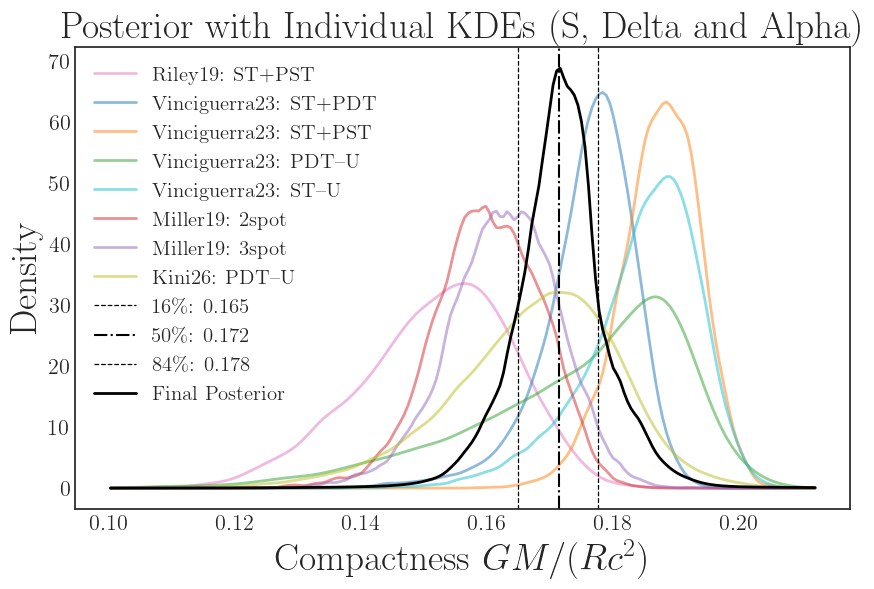

In [7]:
# Plot final posterior with individual measurements 
plt.style.use("seaborn-v0_8-white")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
fig, ax = plt.subplots(figsize=(10, 6))
for key, meta in MODELS.items():
    ax.plot(
        C_grid,
        KDE_grid_values[key],
        color=meta["color"],
        lw=2,
        alpha=0.5,
        label=meta["label"]
    )
    
# 16-50-84 markers
for q, val in zip(quantiles, quantile_values):
    style = "-." if q == 0.5 else "--"
    lw = 1.5 if q == 0.5 else 0.9
    ax.axvline(
        val,
        linestyle=style,
        color="black",
        linewidth=lw,
        label=rf"{int(q*100)}\%: {val:.3f}"
    )

ax.plot(C_grid, final_posterior, color="black", lw=2, alpha=1,label="Final Posterior")
ax.set_xlabel("Compactness $GM/(Rc^2)$", fontsize=27)
ax.set_ylabel("Density", fontsize=27)
ax.set_title("Posterior with Individual KDEs (S, Delta and Alpha)", fontsize=27)
ax.tick_params(labelsize=16)
ax.legend(fontsize=15)
plt.show()

# plt.plot(sigma_grid, posterior_sigma)
# plt.xscale("log")
# plt.title("Posterior over sigma_shift")
# plt.show()

# plt.plot(sigma_grid, evidence_sigma)
# plt.xscale("log")
# plt.title("Evidence vs sigma_shift")
# plt.show()